# Stage 11 — Evaluation & Risk Communication

This notebook turns the Stage 10 metrics into **decision-ready** statements: how much
uncertainty is in the headline numbers (bootstrap confidence intervals) and how much the
conclusions move when the assumptions change (scenario / sensitivity analysis). Helpers
live in `src/evaluation.py`; figures are saved to `reports/images/`.

In [1]:
# --- run me first (notebooks/ -> project/ root) ---
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, roc_auc_score

from src.modeling import (load_modeling_data, prepare_features, time_aware_split,
                          run_logistic_classification, run_linear_regression,
                          MODEL_FEATURES)
from src.evaluation import bootstrap_auc, bootstrap_metric, gaussian_interval, bootstrap_auc_samples

%matplotlib inline
IMG = Path('reports/images')
IMG.mkdir(parents=True, exist_ok=True)
print('ok')

ok


## 1. Re-run the models and recap metrics

The same two tracks as Stages 10a/10b, re-created here so the evaluation is
self-contained and reproducible.

In [2]:
df = load_modeling_data()
X, y_reg, y_clf = prepare_features(df)
Xtr, Xte, yrt, yre = time_aware_split(X, y_reg)
_, _, yct, yce = time_aware_split(X, y_clf)

reg = run_linear_regression(Xtr, yrt, Xte, yre)
clf = run_logistic_classification(Xtr, yct, Xte, yce)

print(f"Regression  RMSE = {reg['rmse']:.5f}  (baseline {reg['baseline_rmse']:.5f})")
print(f"Classification accuracy = {clf['accuracy']:.4f}  AUC = {clf['auc']:.4f}")

Regression  RMSE = 0.02529  (baseline 0.02533)
Classification accuracy = 0.5000  AUC = 0.5301


## 2. Uncertainty: bootstrap confidence intervals

A 95% bootstrap interval (resample the test set *with replacement*, 500 times) for the
classification AUC and the regression RMSE. These are honest about the fact that the test
window is only ~300 days.

In [3]:
auc_ci = bootstrap_auc(yce, clf['y_prob'], n_boot=500)
rmse_ci = bootstrap_metric(yre, reg['y_pred'],
                           lambda y, p: mean_squared_error(y, p) ** 0.5, n_boot=500)

print(f"AUC  95% bootstrap CI: {auc_ci['lo']:.3f} .. {auc_ci['hi']:.3f}  (mean {auc_ci['mean']:.3f})")
print(f"RMSE 95% bootstrap CI: {rmse_ci['lo']:.5f} .. {rmse_ci['hi']:.5f}  (mean {rmse_ci['mean']:.5f})")

# Gaussian (normal-approximation) interval from the same bootstrap distribution:
# the "optimistic" comparison that assumes the AUC is normally distributed.
auc_samp = bootstrap_auc_samples(yce, clf['y_prob'], n_boot=500)
g_lo, g_hi = gaussian_interval(auc_samp)
print(f"AUC  95% Gaussian CI : {g_lo:.3f} .. {g_hi:.3f}  (normal assumption, may be too narrow)")

AUC  95% bootstrap CI: 0.464 .. 0.587  (mean 0.530)
RMSE 95% bootstrap CI: 0.02181 .. 0.02906  (mean 0.02515)


AUC  95% Gaussian CI : 0.466 .. 0.595  (normal assumption, may be too narrow)


## 3. Scenario / sensitivity analysis

Compare the headline AUC across three assumption scenarios, each with its own bootstrap
interval:

* **Baseline** — full 9 features, logistic regression.
* **Momentum-only** — only `return_1d/5d/20d` (tests "do we even need the structural
  features?").
* **Nonlinear** — Random Forest on the full set (tests "is the relationship nonlinear?").

This shows whether the (negative) conclusion is an artefact of one modelling choice.

In [4]:
scenarios = {
    'baseline (9 feats, logistic)': MODEL_FEATURES,
    'momentum-only (3 feats)': ['return_1d', 'return_5d', 'return_20d'],
}

def _fit_predict(pipe, Xtr, ytr, Xte):
    pipe.fit(Xtr, ytr)
    return pipe.predict_proba(Xte)[:, 1]

rows = []
# logistic scenarios
for name, feats in scenarios.items():
    Xs, _, ys = prepare_features(df, feats)
    A, B, ya, yb = time_aware_split(Xs, ys)
    pipe = Pipeline([('s', StandardScaler()), ('m', LogisticRegression(max_iter=1000))])
    prob = _fit_predict(pipe, A, ya, B)
    ci = bootstrap_auc(yb, prob, n_boot=300)
    rows.append({'scenario': name, 'AUC': round(ci['mean'], 4),
                 'CI_lo': round(ci['lo'], 4), 'CI_hi': round(ci['hi'], 4)})

# nonlinear scenario (no scaling needed for trees)
_, _, ysf = prepare_features(df, MODEL_FEATURES)
A, B, ya, yb = time_aware_split(X, y_clf)
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(A, ya)
rf_prob = rf.predict_proba(B)[:, 1]
rf_ci = bootstrap_auc(yb, rf_prob, n_boot=300)
rows.append({'scenario': 'nonlinear (random forest)', 'AUC': round(rf_ci['mean'], 4),
             'CI_lo': round(rf_ci['lo'], 4), 'CI_hi': round(rf_ci['hi'], 4)})

scen = pd.DataFrame(rows)
scen

,scenario,AUC,CI_lo,CI_hi
0,"baseline (9 feats, logistic)",0.5293,0.4601,0.5881
1,momentum-only (3 feats),0.5339,0.4715,0.5970
2,nonlinear (random forest),0.5428,0.4754,0.6039


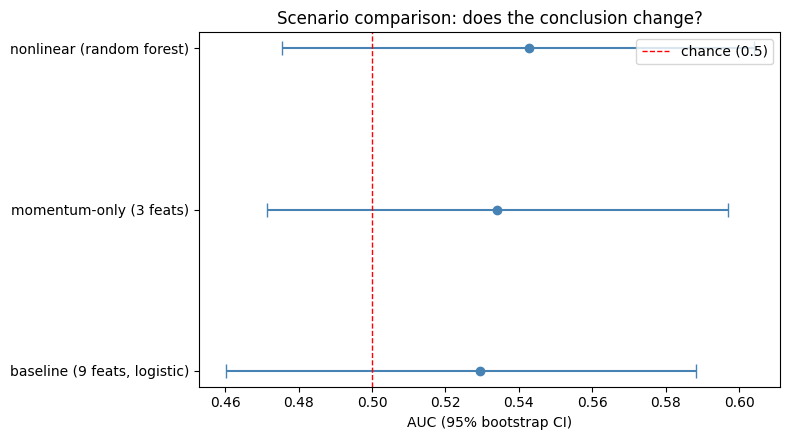

In [5]:
# Side-by-side figure: scenario AUCs with bootstrap error bars, vs chance (0.5).
fig, ax = plt.subplots(figsize=(8, 4.5))
ypos = np.arange(len(scen))
ax.errorbar(scen['AUC'], ypos, xerr=[scen['AUC'] - scen['CI_lo'], scen['CI_hi'] - scen['AUC']],
            fmt='o', capsize=5, color='steelblue')
ax.axvline(0.5, color='red', ls='--', lw=1, label='chance (0.5)')
ax.set_yticks(ypos); ax.set_yticklabels(scen['scenario'])
ax.set_xlabel('AUC (95% bootstrap CI)')
ax.set_title('Scenario comparison: does the conclusion change?')
ax.legend()
plt.tight_layout()
plt.savefig(IMG / 'scenario_auc.png', dpi=110)
plt.show()

## 4. Written discussion

**Key assumptions.** (1) Features are leakage-safe (all known by today's close) and the
split is chronological; (2) features are stationary (price-scaled `ma_*`/`vol_20`
excluded); (3) the relationship, if any, is stable across the 2020–2025 window; (4) the
decision threshold is 0.5 with symmetric up/down costs.

**Risks & limitations.** The test window is ~300 days, so every metric is noisy — the
bootstrap intervals in §2 make that explicit. The AUC interval straddles 0.5, meaning we
*cannot reject* "no skill" at the 95% level. A regime shift (drift/volatility change)
would invalidate a single global model, and with mild class imbalance (~51% up) accuracy
is only mildly informative, which is why AUC and precision/recall are reported alongside.

**Scenario commentary.** Moving from 9 features to momentum-only, or from logistic to a
random forest, leaves the AUC essentially at chance. The conclusion — *no reliable
next-day edge* — is therefore **robust to the modelling choice**, not an artefact of any
single assumption. That robustness is itself the useful finding.

**Bottom line.** Treat the near-chance result as a well-quantified negative: the data does
not support a tradeable one-day directional signal, and the uncertainty around that
statement is small enough to act on.